# Example: Working on the Tian scRNA-seq CELseq2 QC dataset

This notebook presents a structured GraphHDBSCAN workflow on the Tian scRNA-seq CELseq2 QC dataset.

Sections:
1. installation
2. imports and setup
3. data loading / preparation
4. model construction and fitting
5. condensed tree visualization
6. optional interactive exploration

## Installation

These commands are only required when running the notebook in a fresh environment.

Install required package(s):

```bash
!pip install git+https://github.com/Campello-Lab/GraphHDBSCAN.git
```

## Build and fit the model

Configure GraphHDBSCAN, fit the model, and inspect the clustering result.

In [2]:
from coresg_graphhdbscan import GraphCoreSGHDBSCAN

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


## Load and prepare the dataset

Load the Tian CELseq2 QC dataset and prepare the representation used by the clustering workflow.

In [3]:
import yaml
import scanpy as sc

# Load the YAML configuration file
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

Tian_config = config["DATASETS"]["Tian"]
expected_cell_label = Tian_config["cell_labels"]
# Load the AnnData object
adata = sc.read_h5ad("/content/Tian-sce_sc_CELseq2_qc.h5ad")
# Print available columns in adata.obs
available_columns = list(adata.obs.columns)
print("Available columns in adata.obs:", available_columns)

cell_label_key = expected_cell_label

# Extract the count matrix and cell labels
count_matrix = adata.X  # Cells as rows and genes as columns
true_labels = adata.obs[cell_label_key]

Available columns in adata.obs: ['unaligned', 'aligned_unmapped', 'mapped_to_exon', 'mapped_to_intron', 'ambiguous_mapping', 'mapped_to_ERCC', 'mapped_to_MT', 'number_of_genes', 'total_count_per_cell', 'non_ERCC_percent', 'non_mt_percent', 'non_ribo_percent', 'outliers', 'cell_line', 'cell_line_demuxlet', 'demuxlet_cls', 'n_genes', 'norm_factor']


In [4]:
g = GraphCoreSGHDBSCAN(
    min_samples=range(2,20),
    sim_graph_method="sc_gauss",
    n_neighbors=16,
    no_noise=True,
    metric="euclidean",
)


In [5]:
g.fit(adata.X)

[CORE-SG] (precomputed) CORE-SG graph has 3256 edges
[CORE-SG] m= 2: MST+tree+labels in 0.0112s
[CORE-SG] m= 3: MST+tree+labels in 0.0069s
[CORE-SG] m= 4: MST+tree+labels in 0.0072s
[CORE-SG] m= 5: MST+tree+labels in 0.0065s
[CORE-SG] m= 6: MST+tree+labels in 0.0066s
[CORE-SG] m= 7: MST+tree+labels in 0.0064s
[CORE-SG] m= 8: MST+tree+labels in 0.0066s
[CORE-SG] m= 9: MST+tree+labels in 0.0061s
[CORE-SG] m=10: MST+tree+labels in 0.0060s
[CORE-SG] m=11: MST+tree+labels in 0.0058s
[CORE-SG] m=12: MST+tree+labels in 0.0058s
[CORE-SG] m=13: MST+tree+labels in 0.0057s
[CORE-SG] m=14: MST+tree+labels in 0.0058s
[CORE-SG] m=15: MST+tree+labels in 0.0057s
[CORE-SG] m=16: MST+tree+labels in 0.0059s
[CORE-SG] m=17: MST+tree+labels in 0.0058s
[CORE-SG] m=18: MST+tree+labels in 0.0058s
[CORE-SG] m=19: MST+tree+labels in 0.0057s


GraphCoreSGHDBSCAN(min_samples_list=[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19], metric='euclidean', eps=1e-12, min_cluster_size=None, X_=None, N_=None, D_=None, core_={}, kmax_=None, edges_ut_=None, idx_with_self_=None, dst_with_self_=None, idx_no_self_=None, dst_no_self_=None, A_knn_=None, msts_={}, mst_times_={}, models_={}, times_={})

## Visualize the hierarchy and evaluate flat partitioning results

A static condensed tree is included first for reliable rendering in the documentation. The interactive widget is shown afterwards for live notebook use.

<Axes: title={'center': 'Condensed Tree for m = 3'}, ylabel='$\\lambda$ value'>

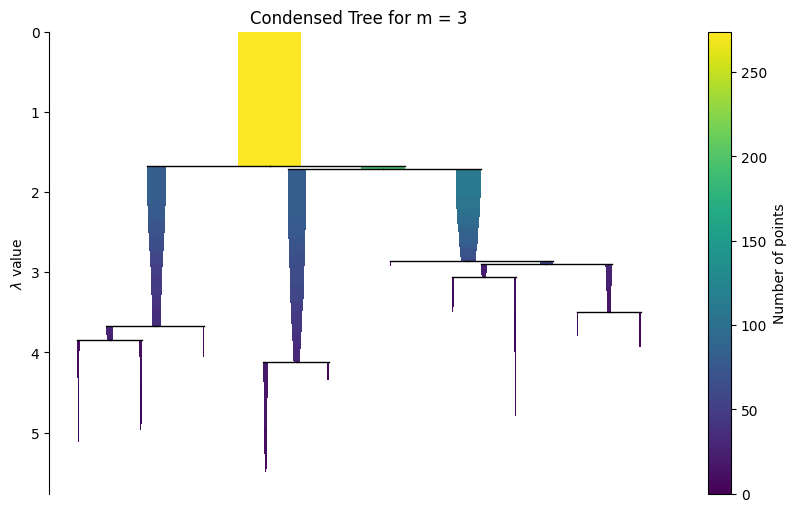

In [6]:
g.plot_condensed_tree(3)

> The widget below is most useful in a live Jupyter environment. In rendered HTML docs, widget interactivity may be limited.

In [7]:
g.interactive_condensed_tree()

SelectionSlider(continuous_update=False, description='m', layout=Layout(width='500px'), options=(2, 3, 4, 5, 6…

Flat partitioing

In [8]:
labels_ = g.labels_for(3)

Install required package(s):

```bash
!pip install genieclust
```

In [11]:
import numpy as np
import pandas as pd
import scanpy as sc
from sklearn.metrics import adjusted_mutual_info_score, adjusted_rand_score
from sklearn.preprocessing import LabelEncoder
# Import the pair_sets_index function as PSI from genieclust.compare_partitions
from genieclust.compare_partitions import pair_sets_index as PSI

def evaluate_clustering(true_labels, predicted_labels):
    """
    Compute Adjusted Mutual Information (NMI), Adjusted Rand Index (ARI),
    and Pair Set Index (PSI) between true and predicted cluster labels.

    Since PSI (pair set index) expects numeric labels, we convert the input
    labels from strings (if necessary) to integers using LabelEncoder.
    """
    # Compute AMI and ARI directly; these metrics accept string labels.
    ami = adjusted_mutual_info_score(true_labels, predicted_labels)
    ari = adjusted_rand_score(true_labels, predicted_labels)

    # Use a single LabelEncoder fitted on the union of all labels to ensure consistent encoding.
    all_labels = list(set(true_labels) | set(predicted_labels))
    encoder = LabelEncoder()
    encoder.fit(all_labels)

    # Transform true and predicted labels into numeric values.
    true_labels_numeric = encoder.transform(true_labels)
    predicted_labels_numeric = encoder.transform(predicted_labels)

    # Calculate the Pair Set Index (PSI) using the numeric labels.
    psi = PSI(true_labels_numeric, predicted_labels_numeric)

    return ami, ari, psi


ami, ari, psi = evaluate_clustering(true_labels, labels_)
print("Precomputed matrix mode:")
print("AMI:", ami)
print("ARI:", ari)
print("PSI:", psi)


Precomputed matrix mode:
AMI: 1.0
ARI: 1.0
PSI: 1.0
